In [ ]:
import pandas as pd
import glob
import os

# === 1. CONFIGURAÇÃO ===
# Altere esta variável para o caminho da pasta onde estão os arquivos .txt
# Exemplo Windows: r'C:\Users\seu_usuario\Documentos\trajetorias\47'
# Exemplo Linux/Mac: '/home/seu_usuario/documentos/trajetorias/47'
users = [11,12,13,14,15,19,21,22,23,24,29,30,35,36,38,47,52,54,60,82]
data_folder = r'Train/47/labels_ftid'

# Monta o padrão de busca para todos os .txt
pattern = os.path.join(data_folder, '*.txt')
txt_files = sorted(glob.glob(pattern))

print(f'Pasta configurada: {data_folder}')
print(f'Quantidade de arquivos .txt encontrados: {len(txt_files)}')

if not txt_files:
    raise FileNotFoundError(
        f'Nenhum arquivo .txt encontrado em {data_folder}. '
        'Verifique o caminho da pasta.'
    )

# === 2. EXTRAI user_id A PARTIR DO NOME DO ARQUIVO ===
# Exemplo de nome: "47_frame_0_with_ftid.txt" -> user_id = "47"
primeiro_nome = os.path.basename(txt_files[0])
user_id = primeiro_nome.split('_')[0]

print(f'user_id detectado a partir dos nomes dos arquivos: {user_id}')

# === 3. LEITURA E CONSOLIDAÇÃO DOS ARQUIVOS ===

frames_list = []

for file_path in txt_files:
    file_name = os.path.basename(file_path)

    # Extrai o número do frame a partir do padrão "_frame_"
    # Ex.: "47_frame_2_with_ftid.txt" -> pega o "2"
    try:
        parte_frame = file_name.split('_frame_')[1]
        # Pega só os dígitos (caso haja algo depois, como "_with_ftid")
        frame_number_str = ''.join(ch for ch in parte_frame if ch.isdigit())
        frame_number = int(frame_number_str)
    except Exception as e:
        print(f'Não foi possível extrair o frame de "{file_name}": {e}')
        continue

    # Lê o arquivo .txt
    # Com base nos exemplos enviados, cada linha tem 6 colunas:
    # id (string), 0 (int), e 4 valores float.
    # Ajuste os nomes abaixo se quiser algo mais semântico.
    try:
        df = pd.read_csv(
            file_path,
            sep=r'\s+',
            header=None,
            names=['trajectory_id', 'ftid', 'x', 'y', 'w', 'h']
        )
    except Exception as e:
        print(f'Erro ao ler "{file_name}": {e}')
        continue

    # Adiciona colunas de contexto
    df['timestamp'] = frame_number
    df['user_id'] = user_id

    frames_list.append(df)

# === 4. CONCATENAÇÃO FINAL ===

if not frames_list:
    raise RuntimeError('Nenhum DataFrame foi criado. Verifique os arquivos e o padrão de leitura.')

trajectories_df = pd.concat(frames_list, ignore_index=True)

# Reorganiza as colunas para deixar user_id/frame primeiro
cols_order = ['user_id', 'timestamp', 'trajectory_id', 'ftid', 'x', 'y', 'w', 'h']
trajectories_df = trajectories_df[cols_order]

print('DataFrame final criado com sucesso!')
print(f'Total de linhas: {len(trajectories_df)}')

trajectories_df = trajectories_df[trajectories_df["ftid"] == 0]
trajectories_df.to_csv("visem47.csv")


Pasta configurada: Train/47/labels_ftid
Quantidade de arquivos .txt encontrados: 1470
user_id detectado a partir dos nomes dos arquivos: 47
DataFrame final criado com sucesso!
Total de linhas: 8035


In [12]:
import pandas as pd
import glob
import os

# === 1. CONFIGURAÇÃO GERAL ===
users = [11,12,13,14,15,19,21,22,23,24,29,30,35,36,38,47,52,54,60,82]
base_folder = r'Train'  # pasta base onde ficam as pastas dos usuários

all_users_frames = []  # para juntar tudo depois (opcional)

for user in users:
    # monta a pasta específica de cada usuário
    data_folder = os.path.join(base_folder, str(user), 'labels_ftid')

    pattern = os.path.join(data_folder, '*.txt')
    txt_files = sorted(glob.glob(pattern))

    print(f'\n=== Usuário {user} ===')
    print(f'Pasta configurada: {data_folder}')
    print(f'Quantidade de arquivos .txt encontrados: {len(txt_files)}')

    if not txt_files:
        print(f'AVISO: Nenhum arquivo .txt encontrado para o usuário {user} em {data_folder}. Pulando...')
        continue

    # user_id pode ser o próprio número da lista
    user_id = str(user)
    print(f'user_id definido como: {user_id}')

    # === 3. LEITURA E CONSOLIDAÇÃO DOS ARQUIVOS DESSE USUÁRIO ===
    frames_list = []

    for file_path in txt_files:
        file_name = os.path.basename(file_path)

        # Extrai o número do frame a partir do padrão "_frame_"
        # Ex.: "47_frame_2_with_ftid.txt" -> pega "2"
        try:
            parte_frame = file_name.split('_frame_')[1]
            frame_number_str = ''.join(ch for ch in parte_frame if ch.isdigit())
            frame_number = int(frame_number_str)
        except Exception as e:
            print(f'Não foi possível extrair o frame de "{file_name}": {e}')
            continue

        try:
            df = pd.read_csv(
                file_path,
                sep=r'\s+',
                header=None,
                names=['trajectory_id', 'ftid', 'x', 'y', 'w', 'h']
            )
        except Exception as e:
            print(f'Erro ao ler "{file_name}": {e}')
            continue

        df['timestamp'] = frame_number
        df['user_id'] = user_id

        frames_list.append(df)

    if not frames_list:
        print(f'AVISO: Nenhum DataFrame foi criado com sucesso para o usuário {user}. Pulando...')
        continue

    trajectories_df = pd.concat(frames_list, ignore_index=True)

    # Reorganiza as colunas
    cols_order = ['user_id', 'timestamp', 'trajectory_id', 'ftid', 'x', 'y', 'w', 'h']
    trajectories_df = trajectories_df[cols_order]

    # filtra ftid == 0 (como você fez antes)
    trajectories_df = trajectories_df[trajectories_df["ftid"] == 0]

    print(f'DataFrame final do usuário {user} criado com sucesso!')
    print(f'Total de linhas: {len(trajectories_df)}')

    # salva CSV por usuário
    output_filename = f"visem{user_id}.csv"
    trajectories_df.to_csv(output_filename, index=False)
    print(f'Arquivo salvo: {output_filename}')

    # acumula para o CSV global (opcional)
    all_users_frames.append(trajectories_df)
'''
# === 5. OPCIONAL: CRIAR UM ÚNICO CSV COM TODOS OS USUÁRIOS ===
if all_users_frames:
    all_df = pd.concat(all_users_frames, ignore_index=True)
    all_df.to_csv("visem_all_users.csv", index=False)
    print('\nArquivo único com todos os usuários salvo como: visem_all_users.csv')
    print(f'Total de linhas (todos os usuários): {len(all_df)}')
else:
    print('\nNenhum usuário teve DataFrame válido gerado.')
    '''



=== Usuário 11 ===
Pasta configurada: Train\11\labels_ftid
Quantidade de arquivos .txt encontrados: 1470
user_id definido como: 11
DataFrame final do usuário 11 criado com sucesso!
Total de linhas: 53854
Arquivo salvo: visem11.csv

=== Usuário 12 ===
Pasta configurada: Train\12\labels_ftid
Quantidade de arquivos .txt encontrados: 1470
user_id definido como: 12
DataFrame final do usuário 12 criado com sucesso!
Total de linhas: 34483
Arquivo salvo: visem12.csv

=== Usuário 13 ===
Pasta configurada: Train\13\labels_ftid
Quantidade de arquivos .txt encontrados: 1470
user_id definido como: 13
DataFrame final do usuário 13 criado com sucesso!
Total de linhas: 61176
Arquivo salvo: visem13.csv

=== Usuário 14 ===
Pasta configurada: Train\14\labels_ftid
Quantidade de arquivos .txt encontrados: 1470
user_id definido como: 14
DataFrame final do usuário 14 criado com sucesso!
Total de linhas: 5029
Arquivo salvo: visem14.csv

=== Usuário 15 ===
Pasta configurada: Train\15\labels_ftid
Quantidade de

'\n# === 5. OPCIONAL: CRIAR UM ÚNICO CSV COM TODOS OS USUÁRIOS ===\nif all_users_frames:\n    all_df = pd.concat(all_users_frames, ignore_index=True)\n    all_df.to_csv("visem_all_users.csv", index=False)\n    print(\'\nArquivo único com todos os usuários salvo como: visem_all_users.csv\')\n    print(f\'Total de linhas (todos os usuários): {len(all_df)}\')\nelse:\n    print(\'\nNenhum usuário teve DataFrame válido gerado.\')\n    '

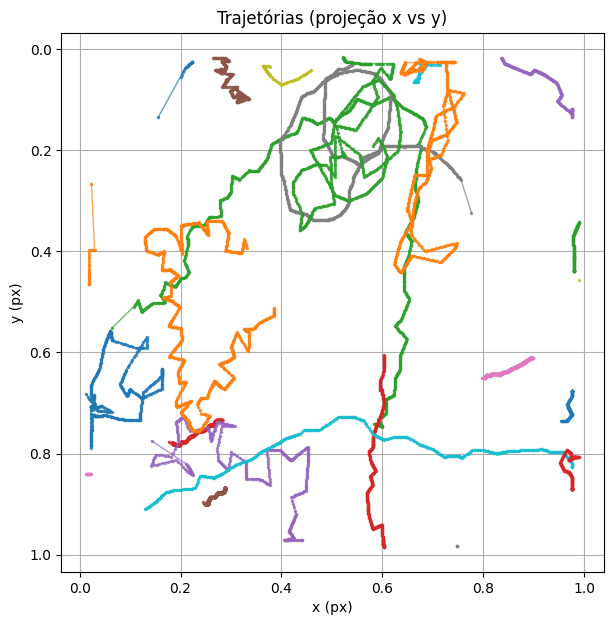

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

for track_id, group in trajectories_df.groupby('trajectory_id'):
    # ordena por frame, só pra garantir
    group_sorted = group.sort_values('timestamp')
    plt.plot(group_sorted['x'], group_sorted['y'], marker='.', linewidth=1, markersize=3, alpha=0.7)

plt.title('Trajetórias (projeção x vs y)')
plt.xlabel('x (px)')
plt.ylabel('y (px)')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()


In [13]:
# %%
# Notebook sem classes — tudo em células diretas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("output_notebook_simplificado")
output_dir.mkdir(exist_ok=True, parents=True)

# %%
# 1. Carregar dataset
# df_raw = pd.read_csv("128_fishing_trajsRugs10.csv")
df_raw = pd.read_csv("visem11.csv")
df_raw = df_raw.sort_values(["trajectory_id", "timestamp"]).reset_index(drop=True)
df_raw.head()

# %%
# 2. Plotar trajetórias originais
plt.figure(figsize=(10, 10))
grouped = df_raw.groupby("trajectory_id")
colors = plt.cm.tab20(np.linspace(0, 1, len(grouped)))

for color, (traj_id, g) in zip(colors, grouped):
    g = g.sort_values("timestamp")
    plt.plot(g["x"], g["y"], color=color, label=f"Traj {traj_id}")

plt.title("Trajetórias originais")
plt.xlabel("X"); plt.ylabel("Y")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.axis("equal"); plt.grid(True, linestyle=":", alpha=0.5)
plt.tight_layout()
plt.savefig(output_dir / "traj_orig.png", dpi=300)
plt.close()

# %%
# 3. Pré-processamento: translação + PCA rotation

df = df_raw.copy()

df['x_translate'] = df.groupby('trajectory_id')['x'].transform(lambda x: x - x.iloc[0])
df['y_translate'] = df.groupby('trajectory_id')['y'].transform(lambda y: y - y.iloc[0])

angles = {}

def pca_angle(x, y):
    X = np.vstack([x, y]).T
    Xc = X - X.mean(axis=0)
    _, _, Vt = np.linalg.svd(Xc, full_matrices=False)
    v1 = Vt[0]
    disp = np.array([x[-1], y[-1]])
    if np.dot(v1, disp) < 0:
        v1 = -v1
    return np.arctan2(v1[1], v1[0])

df['x_rotated'] = np.nan
df['y_rotated'] = np.nan

for tid, g in df.groupby('trajectory_id'):
    x, y = g['x_translate'].to_numpy(), g['y_translate'].to_numpy()
    theta = pca_angle(x, y)
    c, s = np.cos(-theta), np.sin(-theta)
    xr = x * c - y * s
    yr = x * s + y * c
    df.loc[g.index, 'x_rotated'] = xr
    df.loc[g.index, 'y_rotated'] = yr
    angles[tid] = theta

# %%
# 4. Extração de velocidade e ângulo

df = df.sort_values(["trajectory_id", "timestamp"]).reset_index(drop=True)
window = 1

def compute_speed_angle(g):
    dx = g["x_rotated"] - g["x_rotated"].shift(window)
    dy = g["y_rotated"] - g["y_rotated"].shift(window)
    g["speed"] = np.hypot(dx, dy)
    g["angle_deg"] = np.degrees(np.arctan2(dy, dx))
    return g

df = df.groupby("trajectory_id", group_keys=False).apply(compute_speed_angle)

# %%
# 5. Discretização simbólica

median_speed = float(np.nanmedian(df["speed"]))
eps = 1e-3 * median_speed if median_speed > 0 else 1e-6
moving = df["speed"] > eps
q25, q75 = np.quantile(df.loc[moving, "speed"], [0.25, 0.75]) if moving.any() else (0, 0)

def label_speed(v):
    if np.isnan(v): return np.nan
    if v <= eps: return "Parado"
    if v <= q25: return "Lento"
    if v <= q75: return "Médio"
    return "Rápido"

def label_dir(a):
    if np.isnan(a): return np.nan
    a = ((a + 180) % 360) - 180
    if -45 < a <= 45: return "Leste"
    if 45 < a <= 135: return "Norte"
    if a > 135 or a <= -135: return "Oeste"
    return "Sul"

df["speed_label"] = df["speed"].apply(label_speed)
df["dir4_label"] = df["angle_deg"].apply(label_dir)

def combine(s, d):
    if pd.isna(s): return ""
    if s == "Parado": return "Parado"
    if pd.isna(d): return ""
    return s + d

df["symbol"] = df.apply(lambda r: combine(r["speed_label"], r["dir4_label"]), axis=1)

# Lista por trajetória
symbolic = df.groupby("trajectory_id").apply(lambda g: g.sort_values("timestamp")["symbol"].tolist())
symbolic = symbolic.rename("simbolic_movement").reset_index()

# %%
# 6. Clusterização via MFV + MinHash LSH
from datasketch import MinHash, MinHashLSH
from collections import Counter

k = 4

# MFV
mfvs = []
for seq in symbolic["simbolic_movement"]:
    clean = [s for s in seq if s and pd.notna(s)]
    motifs = [tuple(clean[i:i+k]) for i in range(len(clean)-k+1)]
    c = Counter(motifs)
    total = sum(c.values())
    mfvs.append({m: c[m]/total for m in c})

symbolic["MFV"] = mfvs

# MinHash + LSH
lsh = MinHashLSH(threshold=0.2, num_perm=128)
minhashes = {}

for idx, row in symbolic.iterrows():
    m = MinHash(num_perm=128)
    for motif in row["MFV"].keys():
        m.update(str(motif).encode("utf8"))
    key = f"traj_{row['trajectory_id']}"
    minhashes[key] = m
    lsh.insert(key, m)

buckets = {}
for key in minhashes:
    similar = sorted(lsh.query(minhashes[key]))
    buckets[key] = "_".join(similar)

symbolic["lsh_bucket"] = symbolic["trajectory_id"].apply(lambda g: buckets[f"traj_{g}"])

# Mapear clusters
unique_buckets = {b:i for i,b in enumerate(sorted(set(symbolic["lsh_bucket"])))}
symbolic["cluster_id"] = symbolic["lsh_bucket"].map(unique_buckets)

# %%
# 7. Behaviour Rugs

direction_rgb = {
    'Norte':[240/255,239/255,48/255],
    'Leste':[240/255,107/255,48/255],
    'Sul':[141/255,48/255,240/255],
    'Oeste':[48/255,240/255,217/255]
}
speed_factor = {'Parado':0.01,'Lento':0.4,'Médio':0.7,'Rápido':1.0}

def sym2rgb(s):
    if not s or pd.isna(s): return [1,1,1]
    if s == "Parado": return [0.3,0.3,0.3]
    for sp in ["Lento","Médio","Rápido"]:
        if s.startswith(sp):
            d = s[len(sp):]
            base = direction_rgb.get(d, [0,0,0])
            return np.clip(np.array(base)*speed_factor[sp], 0, 1)
    return [0,0,0]

symbolic_sorted = symbolic.sort_values("cluster_id")
max_len = max(len(seq) for seq in symbolic_sorted["simbolic_movement"])
img = np.zeros((len(symbolic_sorted), max_len, 3))

for i, seq in enumerate(symbolic_sorted["simbolic_movement"]):
    row = [sym2rgb(s) for s in seq]
    if len(row) < max_len:
        row += [[0,0,0]]*(max_len-len(row))
    img[i] = row[:max_len]

plt.figure(figsize=(12,0.3*len(symbolic_sorted)))
plt.imshow(img, aspect='auto')
plt.yticks(range(len(symbolic_sorted)), symbolic_sorted["trajectory_id"])
plt.savefig(output_dir/"behaviour_rugs.png", dpi=300, bbox_inches='tight')
plt.close()

C:\Users\ccana\AppData\Local\Temp\ipykernel_20772\1667470139.py:83: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("trajectory_id", group_keys=False).apply(compute_speed_angle)
C:\Users\ccana\AppData\Local\Temp\ipykernel_20772\1667470139.py:120: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  symbolic = df.groupby("trajectory_id").apply(lambda g: g.sort_values("timestamp")["symbol"].tolist())
